# 5.1 Model Validation via IRAC Colour Space

This notebook validates the theoretical AGN models by tracking their position within the IRAC colour-colour space and comparing them against the Lacy selection wedge. Results correspond to Section 5.1 of the paper.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# Ensure the project root is in the path to import the local package
sys.path.append(os.path.abspath('..'))

from src import config
from glass import data_io, composite_math, photometry, visualization, analysis

# PASA publication styling
plt.style.use('default')
visualization.apply_pasa_style()
os.makedirs(config.PROCESSED_DATA_DIR, exist_ok=True)

## 1. Load Configurations and Base Models

Loading the filters, AGN SKIRTOR models, and GALSEDATLAS templates.

In [2]:
# Load Filters
filters = photometry.load_passbands(config.FILTER_PATHS)

# Set specific paths for templates
skirtor_dir = config.SKIRTOR_DIR
brown_dir = config.GALSEDATLAS_DIR

# Load AGN Models
agn_type1 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE1_PARAMS)
agn_type2 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE2_PARAMS)

# Load GALSEDATLAS (Brown) Templates
brown_templates, brown_names = data_io.read_brown_galaxy_templates(brown_dir)

## 2. Generate Composite SEDs and Calculate IRAC Colours

Iterating over the alpha values to calculate composite SEDs for all templates.

In [3]:
results = []
alphas = config.ALPHA_VALUES
z_irac = 0.0 # Restframe for standard Lacy wedge demo

for t_idx, gal_sed in enumerate(brown_templates):
    gal_name = brown_names[t_idx]
    print(f"Processing template {t_idx+1}/{len(brown_templates)}: {gal_name}", end='\r')
    for agn_name, agn_model in [('Type1', agn_type1), ('Type2', agn_type2)]:
        for alpha in alphas:
            comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, alpha)
            f5836, f8045 = photometry.calculate_irac_colours(comp_sed, filters['3.6'], filters['4.5'], filters['5.8'], filters['8.0'], redshift=z_irac)
            
            results.append({
                'Template': gal_name,
                'AGN_Type': agn_name,
                'Alpha': alpha,
                'f5836': f5836,
                'f8045': f8045
            })
df_results = pd.DataFrame(results)
print("\nProcessed all composite combinations.")

Processing template 129/129: UM_461
Processed all composite combinations.


## 3. Colour Evolution Plots (Fig 1 and 2)

Plotting the IRAC colour evolution tracks. Panels are labelled with a title above each subplot rather than an in-axes annotation.

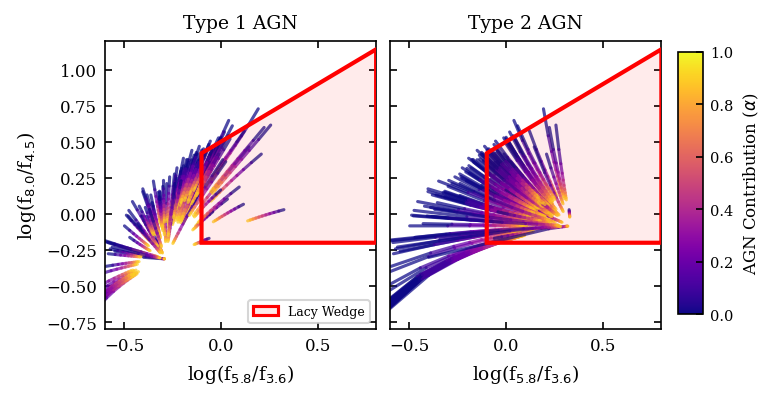

In [4]:
from matplotlib.patches import Patch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5.5, 2.5), sharey=True)
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=0, vmax=1)

for ax, agn_type in [(ax1, 'Type1'), (ax2, 'Type2')]:
    subset = df_results[df_results['AGN_Type'] == agn_type]
    for template in subset['Template'].unique():
        temp_df = subset[subset['Template'] == template].sort_values('Alpha')
        xs, ys = temp_df['f5836'].values, temp_df['f8045'].values
        for i in range(len(temp_df) - 1):
            ax.plot(xs[i:i+2], ys[i:i+2], color=cmap(norm(temp_df['Alpha'].iloc[i])),
                    linewidth=1.5, alpha=0.72, solid_capstyle='round')
    panel_title = 'Type 1 AGN' if agn_type == 'Type1' else 'Type 2 AGN'
    visualization.plot_irac_diagram([], [], ax=ax, title=panel_title)

# Remove duplicate y-axis label and ticks on right panel
ax2.set_ylabel('')

# Legend on left panel only (include Lacy Wedge, remove from ax2)
custom_lines = [
    Patch(facecolor=(1, 0, 0, 0.08), edgecolor='red', lw=1.5, label='Lacy Wedge'),
]
ax1.legend(handles=custom_lines, loc='lower right', fontsize=6)
ax2.get_legend().remove()

# Explicit colorbar axes so it sits flush with the panels
fig.subplots_adjust(wspace=0.05, right=0.80)
cbar_ax = fig.add_axes([0.82, 0.15, 0.03, 0.70])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label(r'AGN Contribution ($\alpha$)', fontsize=8)
cbar.ax.tick_params(labelsize=7)

fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'Paper_IRAC_Evolution_Combined.pdf'), dpi=300, bbox_inches='tight')
plt.show()

## 4. Mean Vector Offset Analysis (Table 2)

Calculating the mean vector displacement for IRAC composites and generating a LaTeX table.

In [5]:
def calculate_irac_offsets(df, agn_type):
    subset = df[df['AGN_Type'] == agn_type]
    offsets = []
    for alpha in subset['Alpha'].unique():
        alpha_df = subset[subset['Alpha'] == alpha]
        initial_df = subset[subset['Alpha'] == 0.0]
        
        x_alpha = alpha_df['f5836'].values
        y_alpha = alpha_df['f8045'].values
        x_init = initial_df['f5836'].values
        y_init = initial_df['f8045'].values
        
        mean_offset = analysis.calculate_mean_vector_offset(x_alpha, y_alpha, x_init, y_init)
        offsets.append({'Alpha': alpha, 'Mean_Offset': mean_offset})
    return pd.DataFrame(offsets)

off1 = calculate_irac_offsets(df_results, 'Type1')
off2 = calculate_irac_offsets(df_results, 'Type2')

table_df = pd.DataFrame({
    r'AGN Contribution (\%)': [int(a*100) for a in alphas],
    'Type 1 Composite': off1['Mean_Offset'].round(2),
    'Type 2 Composite': off2['Mean_Offset'].round(2)
})

display(table_df)
table_df.to_csv(os.path.join(config.PROCESSED_DATA_DIR, 'IRAC_vectoroffset.csv'), index=False)
latex_table = table_df.to_latex(index=False, caption=r"Mean vector offset from the initial position for both AGN Composite Model Types and AGN Contribution amounts for IRAC composites.", label="tab:irac_vectoroffset")
with open(os.path.join(config.PROCESSED_DATA_DIR, 'IRAC_vectoroffset.tex'), 'w') as f:
    f.write(latex_table)

print("Exported IRAC Vector Offset table.")

,AGN Contribution (\%),Type 1 Composite,Type 2 Composite
0,0,0.00,0.00
1,10,0.09,0.24
2,20,0.15,0.35
3,30,0.19,0.42
4,40,0.23,0.47
5,50,0.26,0.51
6,60,0.29,0.54
7,70,0.31,0.56
8,80,0.33,0.58
9,90,0.34,0.60


Exported IRAC Vector Offset table.


## Export: Paper-Required Figures

Copies the subset of plots referenced by `Context/AGNPaper/paper.tex` into `outputs/PaperFigures/`, so that folder always reflects exactly what the paper needs (see `config.PAPER_FIGURE_MANIFEST`).

In [6]:
# Export the subset of plots required by Context/AGNPaper/paper.tex into
# outputs/PaperFigures/, and - if the gitignored Overleaf checkout is present
# locally - straight into its Images/TheoreticalModelPlots/ folder too, so
# the paper never silently references a stale/missing figure.
# (see config.PAPER_FIGURE_MANIFEST for the full list)
import shutil

os.makedirs(config.PAPER_FIGURES_DIR, exist_ok=True)
overleaf_present = os.path.isdir(config.AGNPAPER_DIR)
if overleaf_present:
    os.makedirs(config.PAPER_OVERLEAF_IMAGES_DIR, exist_ok=True)

copied, missing = [], []
for paper_filename, rel_source in config.PAPER_FIGURE_MANIFEST.items():
    src_path = os.path.join(config.PROCESSED_DATA_DIR, rel_source)
    dst_path = os.path.join(config.PAPER_FIGURES_DIR, paper_filename)
    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)
        if overleaf_present:
            shutil.copy2(src_path, os.path.join(config.PAPER_OVERLEAF_IMAGES_DIR, paper_filename))
        copied.append(paper_filename)
    else:
        missing.append(paper_filename)

print(f"Paper figures exported to {config.PAPER_FIGURES_DIR}")
if overleaf_present:
    print(f"  also copied to {config.PAPER_OVERLEAF_IMAGES_DIR}")
print(f"  {len(copied)}/{len(config.PAPER_FIGURE_MANIFEST)} copied")
if missing:
    print("  Still missing (not yet generated by any notebook run):")
    for name in missing:
        print(f"    - {name}")
    print("  Run Paper_Results_Master.ipynb and Model_Validation_via_IRAC.ipynb")
    print("  (both top to bottom) to generate every required source plot.")
else:
    print("  All paper-required figures present.")

Paper figures exported to C:\Users\uqmhooym\OneDrive - The University of Queensland\Documents\GitHub\HonoursResearchProject\outputs\PaperFigures
  also copied to C:\Users\uqmhooym\OneDrive - The University of Queensland\Documents\GitHub\HonoursResearchProject\Context\AGNPaper\Images\TheoreticalModelPlots
  9/12 copied
  Still missing (not yet generated by any notebook run):
    - UVJ_CIGALE_allhosts_fracAGN_colored_combined.pdf
    - UVJ_CIGALE_allhosts_fracAGN_colored_redshift_bins.pdf
    - Paper_UVJ_Contamination_Bias_Summary.pdf
  Run Paper_Results_Master.ipynb and Model_Validation_via_IRAC.ipynb
  (both top to bottom) to generate every required source plot.
